<a href="https://colab.research.google.com/github/Afaluyi/ACE-project/blob/main/Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Directory 'visuals' created.
✅ Data loaded successfully!


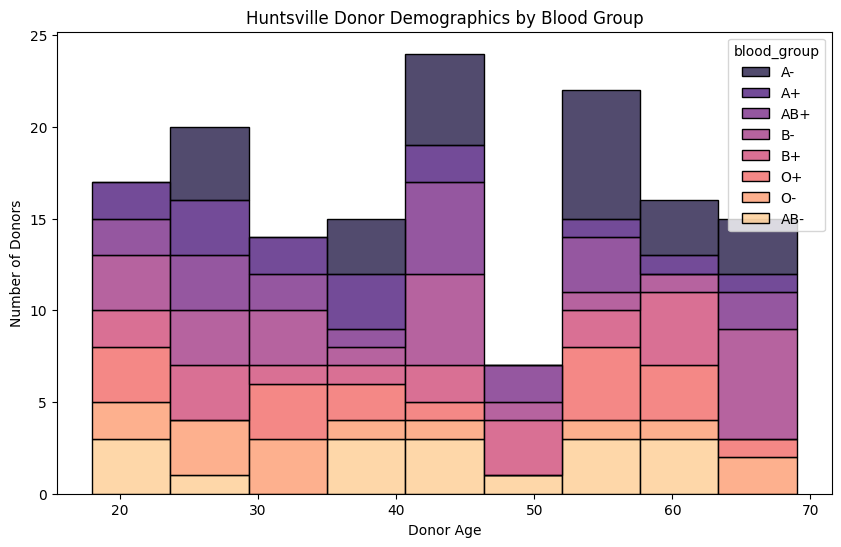

Average Donor Age: 42.7
Most Common Blood Type: A-


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from datetime import datetime

# 1. Setup Folders (This ensures the 'visuals' folder exists for your report images)
if not os.path.exists('visuals'):
    os.makedirs('visuals')
    print("Directory 'visuals' created.")

# 2. Load the data with a check
try:
    # Use 'data/' if you moved the files there, otherwise remove 'data/'
    donors = pd.read_csv('donor_data_clean.csv')
    inventory = pd.read_csv('inventory_levels.csv')
    print("✅ Data loaded successfully!")
except FileNotFoundError:
    print("❌ ERROR: Files not found. Ensure the CSVs are in the same folder as this notebook.")

# 3. Data Processing (The Analytics Part)
donors['last_donation_date'] = pd.to_datetime(donors['last_donation_date'])
today = datetime(2026, 4, 27)
donors['days_since_last'] = (today - donors['last_donation_date']).dt.days

# 4. Create an Actionable Visualization for the Report
plt.figure(figsize=(10, 6))
sns.histplot(data=donors, x='age', hue='blood_group', multiple='stack', palette='magma')
plt.title('Huntsville Donor Demographics by Blood Group')
plt.xlabel('Donor Age')
plt.ylabel('Number of Donors')

# Save this for your Final Report
plt.savefig('visuals/donor_demographics.png')
plt.show()

# 5. Quick Summary for your Executive Summary
print(f"Average Donor Age: {donors['age'].mean():.1f}")
print(f"Most Common Blood Type: {donors['blood_group'].mode()[0]}")